#  Practice wind and sea ice

In [3]:
import xarray as xr
import mod_loading as loader
from importlib import reload
import numpy as np
import pandas as pd
import xarray as xr
from datetime import datetime
from tqdm import tqdm

from datetime import datetime
import gsw
import mod_argo
import matplotlib.pyplot as plt
from cmocean import cm as cmo

import figs_pcm
import mod_pcm
import mod_regression as mod_reg
import mod_preprocessing as mod_prep
reload(mod_reg)


<module 'mod_regression' from '/Users/sangminsong/Library/CloudStorage/OneDrive-UW/Code/CRUSOE/src/mod_regression.py'>

In [ ]:
# year_range = range(2014,2025)
# wind_dict = {k:None for k in [i for i in year_range]}
# for yr in tqdm(year_range):
#     yearly_era5 = xr.open_dataset('../climatedatastore/era5_winds_' + str(yr) + '.nc')
#     yearly_era5['speed'] = np.sqrt(yearly_era5['u10']**2 + yearly_era5['v10']**2)
    
#     yearly_era5.to_netcdf('/Volumes/ocean-repo/era5_wind_speed_' + str(yr) + '.nc')
#     wind_dict[yr] = yearly_era5

NameError: name 'tqdm' is not defined

In [ ]:
winds = xr.open_dataset('/Users/sangminsong/Library/CloudStorage/OneDrive-UW/Code/CRUSOE/climatedatastore/era5_winds_2014.nc')

In [ ]:
# yearly_era5['speed'] = np.sqrt(yearly_era5['u10']**2 + yearly_era5['v10']**2)

In [ ]:
winds

<xarray.Dataset>
Dimensions:     (valid_time: 8760, latitude: 221, longitude: 1440)
Coordinates:
    number      int64 ...
  * valid_time  (valid_time) datetime64[ns] 2014-01-01 ... 2014-12-31T23:00:00
  * latitude    (latitude) float64 -35.0 -35.25 -35.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
    expver      (valid_time) object ...
Data variables:
    u10         (valid_time, latitude, longitude) float32 ...
    v10         (valid_time, latitude, longitude) float32 ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-24T17:41 GRIB to CDM+CF via cfgrib-0.9.1...

In [5]:
temp_2024 = pd.read_csv('../working-vars/regression/P1-processed/socatv2025_test_processed_co2_mld_adt_yr2024_acc20260327.csv', index_col=0)

In [7]:
temp_2024

,cruiseid,datetime,longitude,latitude,linear_time,nearest_profid,prof_datetime,prof_lat,prof_lon,yd_sep,...,sss,mld,adt,atmos_pres_Pa,atmos_pres_atm,vapor_pres_atm,fco2rec,pco2_atmos,pco2_ocean,delta_pco2
6806,096U20240105,2024-01-05 12:26:19,145.71705,-44.72705,3656.518275,6903215_id255,2024-01-10,-43.790252,143.833693,5.199780,...,35.882366,27.302804,0.6885,102460.0,1.011202,0.018539,324.1865,414.543412,325.334404,-89.209007
6807,096U20240105,2024-01-06 12:06:31,142.71100,-46.66590,3657.504525,5905501_id132,2024-01-04,-45.779513,143.122653,1.525359,...,35.106165,21.520078,0.6515,101470.0,1.001431,0.013753,352.3960,412.409016,353.719551,-58.689465
6808,096U20240105,2024-01-07 11:57:49,145.40880,-49.87020,3658.498484,5906209_id143,2024-01-05,-50.733000,147.216000,1.824664,...,34.880166,92.210792,-0.0895,101160.0,0.998372,0.012037,373.2970,411.785824,374.735959,-37.049865
6809,096U20240105,2024-01-08 12:03:51,148.25500,-54.51200,3659.502674,2903453_id028,2024-01-03,-54.371100,146.883700,4.520191,...,34.258183,61.958989,-0.5517,100740.0,0.994226,0.008728,398.1170,411.410734,399.749630,-11.661104
6810,096U20240105,2024-01-09 13:07:23,149.50530,-59.49740,3660.546794,7900637_id200,2024-01-16,-59.663702,149.284939,6.884248,...,34.168063,55.597586,-1.0160,100070.0,0.987614,0.006118,360.2610,409.753503,361.840872,-47.912631
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7235,WFCH20240206,2024-02-20 03:16:55,-136.38265,-73.29205,3702.136748,5906556_id041,2024-02-20,-70.554700,-135.543900,0.001024,...,33.580067,30.405754,-1.1179,100310.0,0.989983,0.005426,250.8455,411.097051,251.970483,-159.126567
7236,WFCH20240206,2024-02-23 17:32:21,-99.91180,-70.46775,3705.730799,3902325_id095,2024-02-24,-67.503000,-103.499490,0.303779,...,33.643676,49.797021,-1.0880,97870.0,0.965902,0.005534,398.7545,400.987695,400.536321,-0.451374
7237,WFCH20240206,2024-03-01 11:50:45,-65.76490,-60.64345,3712.493576,4902638_id004,2024-03-05,-60.798679,-64.430321,4.092535,...,34.055110,42.749931,-0.8436,97710.0,0.964323,0.007141,425.1250,399.609350,426.936046,27.326695
7238,WFCH20240303,2024-03-06 11:26:10,-55.87635,-44.48470,3717.476505,3901565_id124,2024-03-12,-45.024100,-57.620200,6.053501,...,34.406736,21.728755,-0.0622,102080.0,1.007451,0.016576,338.7715,413.803880,339.998145,-73.805735


In [6]:
shipDF = mod_prep.add_wind_speed(temp_2024, year_range = range(2024,2025))

In [ ]:
temp['wind_speed'] = temp['wind_components'].apply(lambda x: np.sqrt(x[0]**2 + x[1]**2))
temp

,cruiseid,datetime,longitude,latitude,linear_time,nearest_profid,prof_datetime,prof_lat,prof_lon,yd_sep,...,vapor_pres_atm,fco2rec,pco2_atmos,pco2_ocean,delta_pco2,year,month,day,wind_components,wind_speed
6806,096U20240105,2024-01-05 12:26:19,145.71705,-44.72705,3656.518275,6903215_id255,2024-01-10,-43.790252,143.833693,5.199780,...,0.018539,324.1865,414.543412,325.334404,-89.209007,2024,1,5,"(4.6773987, 0.9656372)",4.776035
6807,096U20240105,2024-01-06 12:06:31,142.71100,-46.66590,3657.504525,5905501_id132,2024-01-04,-45.779513,143.122653,1.525359,...,0.013753,352.3960,412.409016,353.719551,-58.689465,2024,1,6,"(2.471466, -2.5460052)",3.548280
6808,096U20240105,2024-01-07 11:57:49,145.40880,-49.87020,3658.498484,5906209_id143,2024-01-05,-50.733000,147.216000,1.824664,...,0.012037,373.2970,411.785824,374.735959,-37.049865,2024,1,7,"(8.871109, -7.2168274)",11.435872
6809,096U20240105,2024-01-08 12:03:51,148.25500,-54.51200,3659.502674,2903453_id028,2024-01-03,-54.371100,146.883700,4.520191,...,0.008728,398.1170,411.410734,399.749630,-11.661104,2024,1,8,"(4.917404, -5.070053)",7.063024
6810,096U20240105,2024-01-09 13:07:23,149.50530,-59.49740,3660.546794,7900637_id200,2024-01-16,-59.663702,149.284939,6.884248,...,0.006118,360.2610,409.753503,361.840872,-47.912631,2024,1,9,"(2.138214, -17.89917)",18.026432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7235,WFCH20240206,2024-02-20 03:16:55,-136.38265,-73.29205,3702.136748,5906556_id041,2024-02-20,-70.554700,-135.543900,0.001024,...,0.005426,250.8455,411.097051,251.970483,-159.126567,2024,2,20,"(-6.5198975, -0.71287537)",6.558754
7236,WFCH20240206,2024-02-23 17:32:21,-99.91180,-70.46775,3705.730799,3902325_id095,2024-02-24,-67.503000,-103.499490,0.303779,...,0.005534,398.7545,400.987695,400.536321,-0.451374,2024,2,23,"(12.030548, -2.8300934)",12.358945
7237,WFCH20240206,2024-03-01 11:50:45,-65.76490,-60.64345,3712.493576,4902638_id004,2024-03-05,-60.798679,-64.430321,4.092535,...,0.007141,425.1250,399.609350,426.936046,27.326695,2024,3,1,"(7.3894653, -3.107254)",8.016185
7238,WFCH20240303,2024-03-06 11:26:10,-55.87635,-44.48470,3717.476505,3901565_id124,2024-03-12,-45.024100,-57.620200,6.053501,...,0.016576,338.7715,413.803880,339.998145,-73.805735,2024,3,6,"(-0.095825195, -2.4891968)",2.491040


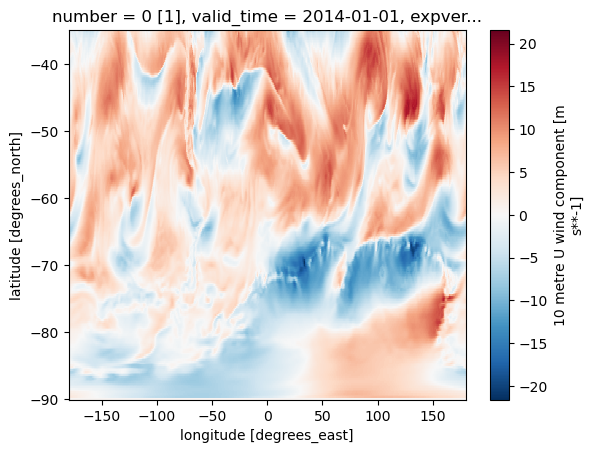

In [5]:
temp = foo.sel(valid_time='2014-01-01T00:00:00.000000000')
temp.u10.plot()

In [25]:
# foo.u10.mean(dim='valid_time').plot()
import mod_ocean

In [6]:
# ==== choose data run parameters
pcm_params='pc8_gmm6'

# ===== import 

# Import clustered data 
[bgcArgo_trainval, bgcArgo_test, 
        socat_trainval, coreArgo_application] = loader.import_p2_clustered(type = 'class-gapfilled', pcm_params=pcm_params)


Importing processed Dataframes with gap-filled classes; pc8_gmm6...
Returned [bgcArgo_trainval(2014-2023), bgcArgo_test(2024), socat_trainval(2014-2023), coreArgo_application(2014-2023)]


In [28]:
inds = bgcArgo_trainval['longitude']>180
bgcArgo_trainval.loc[inds, 'longitude'] = bgcArgo_trainval.loc[inds, 'longitude'].apply(lambda x: x-360)


temp = mod_ocean.expand_datetime(bgcArgo_trainval, type='dataframe')
temp = temp[temp.year==2014]

In [13]:
row = bgcArgo_trainval.iloc[0]

def get_row_windspeeed(row):
    yearly_era5 = foo.copy()

    nearest_wind_speed = yearly_era5.sel(longitude=row.longitude, latitude=row.latitude, valid_time = row.datetime,
                        method='nearest')['speed'].values
    return nearest_wind_speed

get_row_windspeeed(row)


array(9.465874, dtype=float32)

In [14]:
bgcArgo_trainval['wind_speed'] = bgcArgo_trainval.apply(lambda row: get_row_windspeeed(row), axis=1)

# Sea ice

In [ ]:
yearly_seaice = xr.open_dataset('/Volumes/crusoe-repo/data/nsidc-seaice/sic_pss25_20140101-20141231_v06r00.nc')
yearly_seaice.x

<xarray.DataArray 'x' (x: 316)>
array([-3937500., -3912500., -3887500., ...,  3887500.,  3912500.,  3937500.])
Coordinates:
  * x        (x) float64 -3.938e+06 -3.912e+06 ... 3.912e+06 3.938e+06
Attributes:
    standard_name:          projection_x_coordinate
    long_name:              x coordinate of projection
    units:                  meters
    axis:                   X
    valid_range:            [-3950000.  3950000.]
    coverage_content_type:  coordinate

In [57]:
# import pyproj

def get_nearest_seaice(row):
    yearly_seaice = xr.open_dataset('/Volumes/crusoe-repo/data/nsidc-seaice/sic_pss25_20140101-20141231_v06r00.nc')

    transformer = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:3412", always_xy=True)
    x_meters, y_meters = transformer.transform(row.longitude, row.latitude)
    nearest_value = yearly_seaice.sel(x=x_meters, y=y_meters, time = row.datetime, method='nearest')['cdr_seaice_conc'].values
    return nearest_value

temp['sea_ice_conc'] = temp.apply(lambda row: get_nearest_seaice(row), axis=1)
# row = temp.iloc[10]


(array([282.,   0.,   1.,   0.,   0.,   0.,   1.,   1.,   2.,  13.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

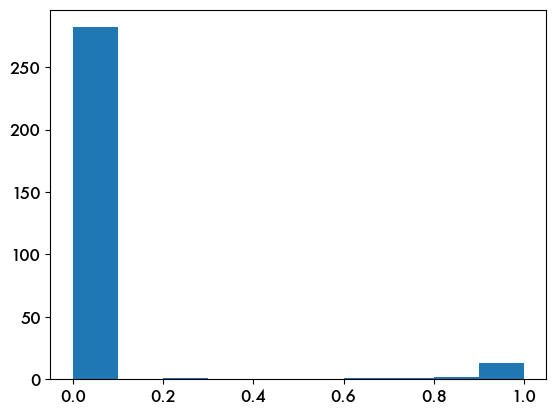

In [60]:
plt.hist(temp.sea_ice_conc)